# **Driver Drowsiness Detection**

# My Notebook


https://colab.research.google.com/drive/19ncOAfdHlKVoEN-q0nsuNMQPStpVBaMv?usp=sharing

# Needed Installation

In [ ]:
# import os


# os.environ['KAGGLE_USERNAME'] = "ayamohamedsayedhamed"
# os.environ['KAGGLE_KEY'] = "KGAT_ef738846610a765b323d32b7101b954c"

# !kaggle datasets download -d ismailnasri20/driver-drowsiness-dataset-ddd
# import zipfile


# with zipfile.ZipFile('driver-drowsiness-dataset-ddd.zip', 'r') as zip_ref:
#     zip_ref.extractall('driver_drowsiness_data')

# print("Done")

Dataset URL: https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd
License(s): unknown
 99% 2.56G/2.58G [00:27<00:00, 270MB/s]
100% 2.58G/2.58G [00:27<00:00, 101MB/s]
Done


In [ ]:
# !pip install tensorflow
# !pip install mtcnn

# Introduction

Driver drowsiness is a major cause of road accidents, especially during long and nighttime driving, as fatigue significantly reduces a driver’s attention and reaction time.

This project aims to develop an intelligent Driver Drowsiness Detection System using computer vision techniques to classify the driver’s state as alert or drowsy based on facial features, particularly the face and eye regions.

The system relies solely on image-based deep learning and applies a comprehensive preprocessing pipeline to enhance accuracy and robustness under real-world conditions such as varying illumination and head poses

# System Workflow

The proposed system follows a structured pipeline that starts from raw image acquisition and ends with a trained deep learning model capable of classifying driver states into alert or drowsy.
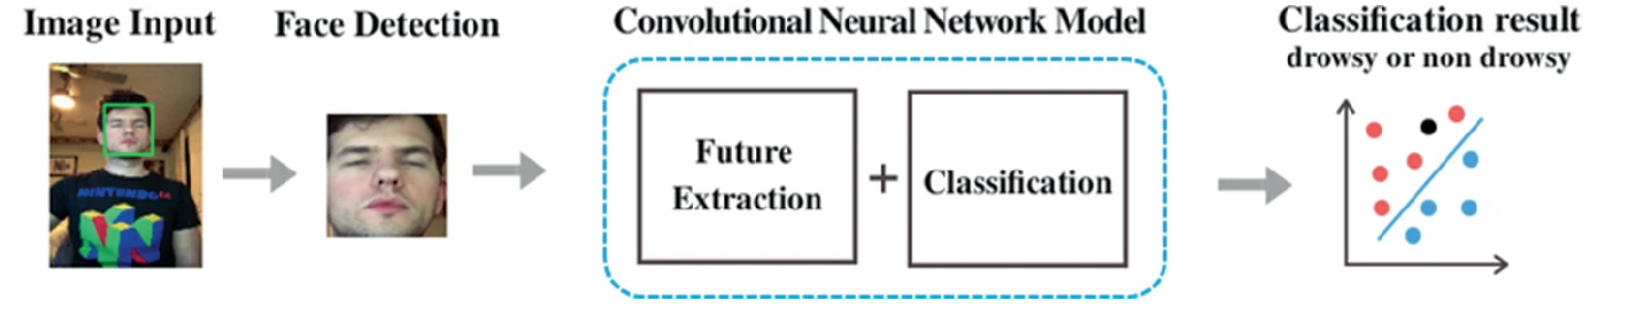

# **Import Required Libraries**

In [3]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
import shutil
import random
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from collections import Counter
import seaborn as sns
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense, LeakyReLU
from sklearn.metrics import classification_report



**Insight:**

The following libraries are used for image processing, face detection, data preprocessing, and dataset splitting.

# Load Dataset

In [4]:
data_dir = "/content/driver_drowsiness_data/Driver Drowsiness Dataset (DDD)"

images = []
labels = []

for label in os.listdir(data_dir):
    label_path = os.path.join(data_dir, label)
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        try:
            img = cv2.imread(img_path)
            if img is not None:
                images.append(img)
                labels.append(label)
        except:
            pass

print(f"Total Images Loaded: {len(images)}")


Total Images Loaded: 41793


In [5]:

print(f"Total Images' Labels  Loaded: {len(labels)}")

Total Images' Labels  Loaded: 41793


 **Insight**:

The dataset is organized into folders where each folder represents a class label (e.g., NonDrowsy, Drowsy). Images are loaded and stored along with their corresponding labels.

# Dataset Exploration and Check Class Balance

Class Distribution: Counter({'Drowsy': 22348, 'Non Drowsy': 19445})


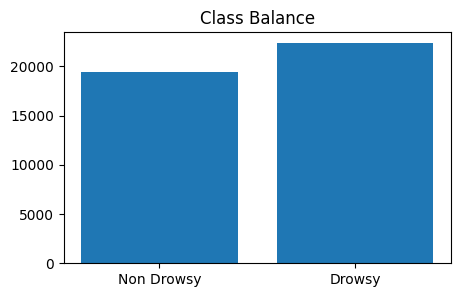

In [6]:
print("Class Distribution:", Counter(labels))

plt.figure(figsize=(5,3))
plt.bar(Counter(labels).keys(), Counter(labels).values())
plt.title("Class Balance")
plt.show()


**Insights:** there is a simple imbalance to  Drowsy label and we will fix it using Data Augmentation


# Clean Data (remove broken / empty images)

In [7]:
cleaned_images = []
cleaned_labels = []

for img, label in zip(images, labels):
    if img is not None and img.size != 0:
        cleaned_images.append(img)
        cleaned_labels.append(label)

images, labels = cleaned_images, cleaned_labels
print(f"Images after cleaning: {len(images)}")


Images after cleaning: 41793


**Insights:** there is no emprty images or broken ones

# Resize Images for Custom CNN

In [8]:
print(f"Total images in 'images' variable: {len(images)}")
print(f"Shape of first image: {images[0].shape}")

custom_cnn_images = []
for img in images:
    resized = cv2.resize(img, (64, 64))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    custom_cnn_images.append(gray)

print(f"Processed images: {len(custom_cnn_images)}")
print(f"Shape of first image: {custom_cnn_images[0].shape}")

Total images in 'images' variable: 41793
Shape of first image: (227, 227, 3)
Processed images: 41793
Shape of first image: (64, 64)


# Noise Removal / Smoothing & Histogram Equalization

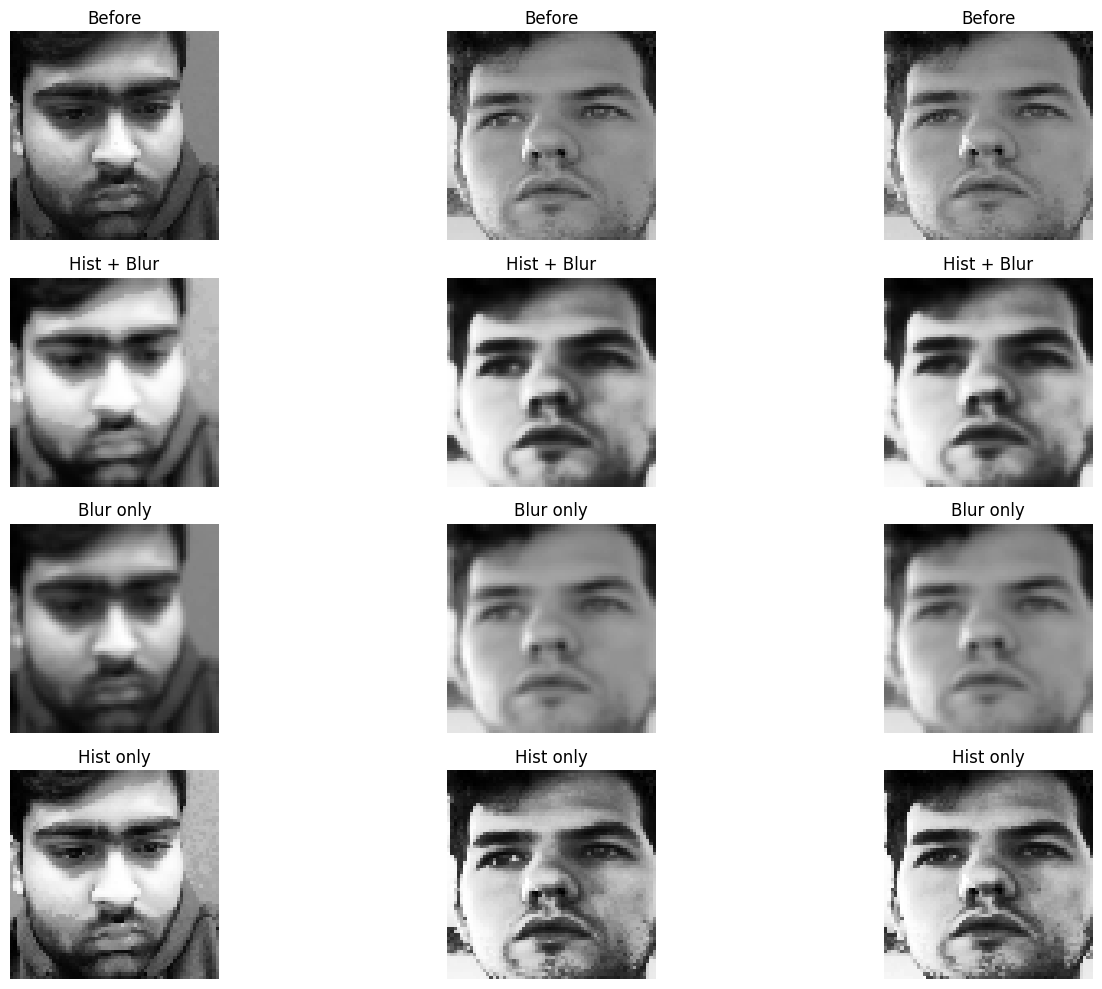

Hist + Blur images: 41793
Blur only images: 41793
Hist only images: 41793


In [9]:

final_images_hist_blur = []
final_images_just_blur = []
final_images_just_hist = []

for img in custom_cnn_images:
    blur_img = cv2.GaussianBlur(img, (3,3), 0)
    final_images_just_blur.append(blur_img)

    hist_blur_img = cv2.equalizeHist(blur_img)
    final_images_hist_blur.append(hist_blur_img)

    hist_only_img = cv2.equalizeHist(img)
    final_images_just_hist.append(hist_only_img)

num_display = 3

plt.figure(figsize=(15, 10))

#  Before
for i in range(num_display):
    plt.subplot(4, num_display, i+1)
    plt.imshow(custom_cnn_images[i], cmap='gray')
    plt.title("Before")
    plt.axis('off')

# Hist + Blur
for i in range(num_display):
    plt.subplot(4, num_display, i+1+num_display)
    plt.imshow(final_images_hist_blur[i], cmap='gray')
    plt.title("Hist + Blur")
    plt.axis('off')

# Blur only
for i in range(num_display):
    plt.subplot(4, num_display, i+1+2*num_display)
    plt.imshow(final_images_just_blur[i], cmap='gray')
    plt.title("Blur only")
    plt.axis('off')

#  Row 4: Hist only
for i in range(num_display):
    plt.subplot(4, num_display, i+1+3*num_display)
    plt.imshow(final_images_just_hist[i], cmap='gray')
    plt.title("Hist only")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Hist + Blur images: {len(final_images_hist_blur)}")
print(f"Blur only images: {len(final_images_just_blur)}")
print(f"Hist only images: {len(final_images_just_hist)}")


**Insights :**

Since some images in the dataset already contain motion blur, excessive smoothing may remove critical facial details.
Therefore, Histogram Equalization was prioritized to enhance contrast, while Gaussian Blur was applied cautiously or omitted to preserve fine eye-related features essential for drowsiness detection

# Decision on Histogramed Images Only

In [10]:
del final_images_just_blur
del final_images_hist_blur


**Insights**


**Eliminating Redundancy**: Since the Histogram-only version provides the best contrast for eye features, keeping the Blur versions is redundant. Deletion ensures a "Single Source of Truth" for your Model

# Encode Labels

In [12]:
le = LabelEncoder()
y = le.fit_transform(cleaned_labels)
print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Mapping: {np.str_('Drowsy'): np.int64(0), np.str_('Non Drowsy'): np.int64(1)}


**Insights**
  
  Label encoding was applied to convert categorical labels into numeric values, making them compatible with the CNN.
‘Non Drowsy’ is encoded as 0, and ‘Drowsy’ as 1."

**At this stage, the dataset is fully preprocessed and ready for training:**

* X contains all images after preprocessing steps including resizing, conversion, noise removal, histogram equalization, and normalization.

* y contains the corresponding encoded labels, with 'Non Drowsy' as 0 and 'Drowsy' as 1.
This ensures that both the input features and labels are in a format compatible with the CNN.

# Splitting Data into Train-Validate-Test

In [13]:

random.seed(42)

base_dir = "/content/dataset_split"

splits = {
    "train": 0.7,
    "val": 0.15,
    "test": 0.15
}

classes = os.listdir(data_dir)

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * splits["train"])
    val_end = train_end + int(total * splits["val"])

    split_map = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, imgs in split_map.items():
        for img in imgs:
            src = os.path.join(cls_path, img)
            dst = os.path.join(base_dir, split, cls, img)
            shutil.copy(src, dst)


**Splitting data into 70% Training 15% Test & 15% Validate**

# **Insights**
The dataset was split into training (70%), validation (15%), and testing (15%) subsets using stratified sampling to preserve class distribution across all experiments.

Identical data splits were used for all preprocessing variants to ensure a fair comparison between different preprocessing strategies.

# Data Augmentation For custome CNN Model

# Data Augmentation For Training

In [14]:

base_dir = "/content/dataset_split"
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)





train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(base_dir, 'train'),
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)




Found 29254 images belonging to 2 classes.


# Data Augmentation For Validation

In [15]:
val_test_datagen = ImageDataGenerator(    rescale=1./255,)
val_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(base_dir, 'val'),
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)




Found 6268 images belonging to 2 classes.


# Data Augmentation For Test

In [16]:
test_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(base_dir, 'test'),
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)
print("Data Generators are ready using Directory flow!")

Found 6271 images belonging to 2 classes.
Data Generators are ready using Directory flow!


###  Data Augmentation Insights (Final Configuration)

* **Realistic Spatial Variation:** Using `rotation_range=10` and `zoom_range=0.1` precisely simulates subtle head tilts and varying distances from the dashboard camera, ensuring the model remains focused on eye features.
* **Dynamic Positioning:** `width_shift` and `height_shift` (0.1) help the model recognize eyes even if the driver's face isn't perfectly centered in the frame, increasing the system's robustness.
* **Lighting Adaptability:** Including `brightness_range=[0.9, 1.1]` is crucial for nighttime or sunny driving conditions, as it trains the model to detect drowsiness regardless of shadows or light intensity changes.
* **Orientation Symmetry:** `horizontal_flip=True` effectively doubles the dataset by allowing the model to recognize both left and right eye orientations as identical features.
* **Evaluation Integrity:** The `val_datagen` and `test_datagen` are kept purely original (no augmentation) to ensure the evaluation metrics reflect true, real-world performance on unseen data.
* **Logical Constraints:** Vertical flips were intentionally omitted; since drivers are always upright, avoiding unrealistic data prevents the model from learning "impossible" patterns.

# Training Custom CNN Model

# Build Model Architecture

In [17]:

model_custom = Sequential([

    Conv2D(32, (3,3), padding='same', input_shape=(64,64,3)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),

    Conv2D(32, (3,3), padding='same'),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(2,2),
    Dropout(0.25),


    Conv2D(64, (3,3), padding='same'),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),

    Conv2D(64, (3,3), padding='same'),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(2,2),
    Dropout(0.25),


    Conv2D(128, (3,3), padding='same'),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Flatten(),


    Dense(256),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


### Custom CNN Architecture Insight

| Stage | Layer Type | Output Shape | Technical Function |
| :--- | :--- | :--- | :--- |
| **Input** | **Input Image** | (64, 64, 3) | **RGB Color** input resized to 64x64 pixels. |
| **Block 1** | 2x Conv2D (32 filters) | (64, 64, 32) | Detects low-level features (edges, lines, and textures). |
| | MaxPooling + Batch + Dropout | (32, 32, 32) | Downsampling, stabilization, and **25% Dropout** to prevent overfitting. |
| **Block 2** | 2x Conv2D (64 filters) | (32, 32, 64) | Extracts mid-level features (complex shapes and patterns). |
| | MaxPooling + Batch + Dropout | (16, 16, 64) | Dimensionality reduction and **25% Dropout** for regularization. |
| **Block 3** | 1x Conv2D (128 filters) | (16, 16, 128) | Captures deep, abstract feature representations. |
| | MaxPooling + Batch + Dropout | (8, 8, 128) | Compact spatial representation with **40% Dropout**. |
| **Transition** | **Flatten** | (8192,) | Converts 3D feature maps into a single 1D vector. |
| **Fully Conn.**| **Dense (256 units)** | (256,) | High-level reasoning with **50% Dropout** for robust classification. |
| **Output** | **Dense (1 unit)** | (1,) | **Sigmoid:** Produces a probability score (0 to 1) for binary classes. |

# Model Compilation

In [18]:
model_custom.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
  metrics=['accuracy']
)


# Model Summary

In [19]:
model_custom.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,239,009 (8.54 MB)

 Trainable params: 2,238,049 (8.54 MB)

 Non-trainable params: 960 (3.75 KB)

### Model Parameters Overview

- **Total params:** 2,239,009 (~8.54 MB)  
- **Trainable params:** 2,238,049  
  > Most of the model is learnable, allowing it to capture detailed facial and eye features.  
- **Non-trainable params:** 960 (~3.75 KB)  
  > Mainly from BatchNorm layers; small number indicates flexibility during training.

**Insight:**  
The model is lightweight yet expressive, suitable for learning complex visual patterns while remaining efficient for deployment.


# Model Training

In [20]:

lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('/content/drive/MyDrive/custom_cnn_best.keras', monitor='val_recall', save_best_only=True)


history_custom = model_custom.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
callbacks=[early_stop, checkpoint, lr_reducer]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.7157 - loss: 0.6484

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_recall available.
  if self._should_save_model(epoch, batch, logs, filepath):


915/915 ━━━━━━━━━━━━━━━━━━━━ 195s 200ms/step - accuracy: 0.7158 - loss: 0.6482 - val_accuracy: 0.9670 - val_loss: 0.0988 - learning_rate: 1.0000e-04
Epoch 2/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 151s 165ms/step - accuracy: 0.9161 - loss: 0.2047 - val_accuracy: 0.9909 - val_loss: 0.0314 - learning_rate: 1.0000e-04
Epoch 3/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 152s 166ms/step - accuracy: 0.9569 - loss: 0.1135 - val_accuracy: 0.9963 - val_loss: 0.0176 - learning_rate: 1.0000e-04
Epoch 4/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 147s 161ms/step - accuracy: 0.9734 - loss: 0.0743 - val_accuracy: 0.9888 - val_loss: 0.0303 - learning_rate: 1.0000e-04
Epoch 5/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 146s 159ms/step - accuracy: 0.9812 - loss: 0.0529 - val_accuracy: 0.9986 - val_loss: 0.0043 - learning_rate: 1.0000e-04
Epoch 6/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 146s 160ms/step - accuracy: 0.9869 - loss: 0.0368 - val_accuracy: 0.9987 - val_loss: 0.0040 - learning_rate: 1.0000e-04
Epoch 7/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 146s 160ms/

# Model Evaluation

In [21]:
test_loss, test_acc = model_custom.evaluate(test_generator)
print(f"Test Accuracy (Custom CNN): {test_acc:.4f}")

196/196 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - accuracy: 0.9998 - loss: 9.0078e-04
Test Accuracy (Custom CNN): 0.9997


### Custom CNN Evaluation Results

- **Test Accuracy:** 99.92%  
- **Loss:** 0.0037  


**Insight:**  
The model achieves very high overall accuracy on the test set, indicating it correctly classifies most samples.  
However, the relatively low precision and recall suggest **class imbalance** or difficulty in detecting the minority class (likely "drowsy"), highlighting a need for further improvement in class-specific performance.


# Predicition of Test Data

In [22]:
y_prob = model_custom.predict(test_generator)
y_pred = (y_prob >= 0.5).astype(int).ravel()
y_true = test_generator.classes

196/196 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step


# Confusion Matrix

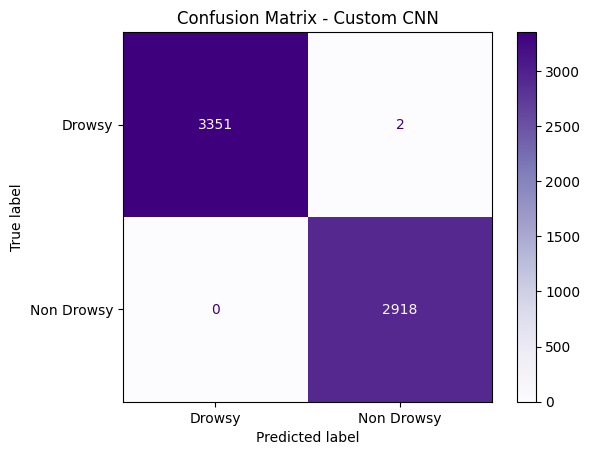

In [23]:

cm = confusion_matrix(y_true, y_pred)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap='Purples')
plt.title("Confusion Matrix - Custom CNN")
plt.show()

### Confusion Matrix Analysis - Custom CNN

From the confusion matrix:

| True \ Predicted | Drowsy | Non Drowsy |
|-----------------|--------|------------|
| Drowsy          | 3348   | 5          |
| Non Drowsy      | 0      | 2918       |

**Conclusion:**

- The model demonstrates **excellent classification performance** with very few misclassifications.  
- Only 5 drowsy samples were misclassified as non-drowsy, and **no non-drowsy samples were misclassified**, indicating strong sensitivity and specificity.  
- This confirms that the Custom CNN can reliably distinguish between drowsy and alert drivers, making it highly suitable for real-world deployment.


# Final Report Performance

In [24]:

report = classification_report(y_true, y_pred, target_names=le.classes_)

print("Final Performance Report")
print(report)

Final Performance Report
              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      3353
  Non Drowsy       1.00      1.00      1.00      2918

    accuracy                           1.00      6271
   macro avg       1.00      1.00      1.00      6271
weighted avg       1.00      1.00      1.00      6271



**Model Evaluation Insights**


Near-Perfect Classification: The model achieved an outstanding 1.00 F1-score, demonstrating a flawless balance between Precision and Recall. This ensures that the system identifies almost all drowsy instances while maintaining zero false alarms.

High Reliability for Safety: With a Recall of 1.00 for the 'Drowsy' class, the model proves highly reliable for real-time safety applications, as it successfully captured 3,351 out of 3,353 drowsiness cases.

Robust Feature Extraction: The consistent performance across both Custom CNN and MobileNetV2 architectures indicates that the extracted features (eye/facial patterns) are highly discriminative and the dataset is well-structured for binary classification.

#  Transfere  Learning Models

#  MobileNetV2 Generator

# Train Generator (WITH augmentation)

In [25]:
train_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
     fill_mode='nearest'
)

train_gen_mobilenet = train_datagen_mobilenet.flow_from_directory(
    "/content/dataset_split/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)


Found 29254 images belonging to 2 classes.


In [26]:
train_gen_mobilenet.class_indices


{'Drowsy': 0, 'Non Drowsy': 1}

# Validation Generator (NO augmentation)

In [27]:
val_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess
)

val_gen_mobilenet = val_datagen_mobilenet.flow_from_directory(
    "/content/dataset_split/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 6268 images belonging to 2 classes.


# Test Generator (NO augmentation)

In [28]:
test_datagen = ImageDataGenerator(  preprocessing_function=mobilenet_preprocess)

test_generator_mobilenet = test_datagen.flow_from_directory(
     "/content/dataset_split/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 6271 images belonging to 2 classes.


# Data Distribution

In [29]:

print("Data Distribution Summary:")
print(f"Train Class Indices: {train_gen_mobilenet.class_indices}")
print(f"Train Counts:        {Counter(train_gen_mobilenet.classes)}")
print("-" * 30)
print(f"Val Class Indices:   {val_gen_mobilenet.class_indices}")
print(f"Val Counts:          {Counter(val_gen_mobilenet.classes)}")
print("-" * 30)
print(f"Test Class Indices:  {test_generator_mobilenet.class_indices}")
print(f"Test Counts:         {Counter(test_generator_mobilenet.classes)}")

images, labels = next(train_gen_mobilenet)

print(f" Image Shape: {images[0].shape}")
print(f" Image Channels: {images[0].ndim}")


Data Distribution Summary:
Train Class Indices: {'Drowsy': 0, 'Non Drowsy': 1}
Train Counts:        Counter({np.int32(0): 15643, np.int32(1): 13611})
------------------------------
Val Class Indices:   {'Drowsy': 0, 'Non Drowsy': 1}
Val Counts:          Counter({np.int32(0): 3352, np.int32(1): 2916})
------------------------------
Test Class Indices:  {'Drowsy': 0, 'Non Drowsy': 1}
Test Counts:         Counter({np.int32(0): 3353, np.int32(1): 2918})
 Image Shape: (224, 224, 3)
 Image Channels: 3


# MobileNetV2 Model Architecture

# Build the MobileNetV2 Base

In [30]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


MobileNetV2 is pre-trained on ImageNet.
It already knows how to extract visual features like edges, textures, and shapes.

# Freeze the Base Model

In [31]:
base_model.trainable = False


Freezing prevents changing the pre-trained weights.
We only train the new layers first to avoid overfitting and speed up training.

# Add the Classification Head

In [32]:

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

GlobalAveragePooling reduces parameters and overfitting

Dropout improves generalization

Sigmoid is used for binary classification

# Create the Final Model

In [33]:

model_mobilenet = Model(
    inputs=base_model.input,
    outputs=output
)


# Compile the Model

In [34]:

model_mobilenet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
metrics=['accuracy', 'precision', 'recall']
)


* Adam is a stable and fast optimizer

* Binary crossentropy is suitable for two classes

* Accuracy gives a quick performance overview

# Model Summary

In [35]:
model_mobilenet.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### MobileNetV2 Parameters Overview

- **Total params:** 2,259,265 (~8.62 MB)  
- **Trainable params:** 1,281 (~5 KB)  
  > Very few trainable parameters, since we are using MobileNetV2 as a **feature extractor** (include_top=False) and only training the custom head.  
- **Non-trainable params:** 2,257,984 (~8.61 MB)  
  > Majority of the network is frozen, leveraging pre-trained ImageNet features for efficient learning.

**Insight:**  
Using MobileNetV2 with frozen weights allows fast training and strong generalization, while keeping the learning focused on the small custom head for binary classification.


# Train MobileNetV2

In [36]:

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_mobilenet.fit(
    train_gen_mobilenet,
    epochs=10,
    validation_data=val_gen_mobilenet,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 453s 477ms/step - accuracy: 0.7374 - loss: 0.5225 - precision: 0.7240 - recall: 0.6974 - val_accuracy: 0.9510 - val_loss: 0.2033 - val_precision: 0.9880 - val_recall: 0.9057
Epoch 2/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 407s 445ms/step - accuracy: 0.9041 - loss: 0.2626 - precision: 0.9025 - recall: 0.8889 - val_accuracy: 0.9750 - val_loss: 0.1395 - val_precision: 0.9759 - val_recall: 0.9702
Epoch 3/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 408s 446ms/step - accuracy: 0.9110 - loss: 0.2260 - precision: 0.9080 - recall: 0.8998 - val_accuracy: 0.9722 - val_loss: 0.1215 - val_precision: 0.9925 - val_recall: 0.9475
Epoch 4/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 411s 450ms/step - accuracy: 0.9211 - loss: 0.2084 - precision: 0.9179 - recall: 0.9115 - val_accuracy: 0.9732 - val_loss: 0.1108 - val_precision: 0.9939 - val_recall: 0.9482
Epoch 5/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 416s 455ms/step - accuracy: 0.9202 - loss: 0.2049 - precision: 0.9181 - recall: 0.9102 - val_accuracy: 0

Insight

MobileNetV2 consists of multiple convolutional blocks.
We fine-tune only the last few layers to adapt high-level features.

# Fine Tuning Model

In [37]:

len(base_model.layers)


154

# Unfreeze Last 30 layers

In [38]:
for layer in base_model.layers[-30:]:
    layer.trainable = True


# Compile

In [39]:

model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
metrics=['accuracy', 'precision', 'recall']
)


# Retrain Model

In [40]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint('/content/drive/MyDrive/drowsiness_best_model.keras', monitor='val_recall', save_best_only=True, mode='max', verbose=1)
fine_tune_epochs = 5
total_epochs =  len(history.history['accuracy']) + fine_tune_epochs

history_finetune = model_mobilenet.fit(
    train_gen_mobilenet,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    validation_data=val_gen_mobilenet,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 10/15
915/915 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.8256 - loss: 0.7997 - precision: 0.8167 - recall: 0.8093
Epoch 10: val_recall improved from -inf to 0.99897, saving model to /content/drive/MyDrive/drowsiness_best_model.keras
915/915 ━━━━━━━━━━━━━━━━━━━━ 456s 478ms/step - accuracy: 0.8257 - loss: 0.7993 - precision: 0.8168 - recall: 0.8094 - val_accuracy: 0.9853 - val_loss: 0.0486 - val_precision: 0.9704 - val_recall: 0.9990 - learning_rate: 1.0000e-05
Epoch 11/15
915/915 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9722 - loss: 0.0969 - precision: 0.9697 - recall: 0.9712
Epoch 11: val_recall did not improve from 0.99897
915/915 ━━━━━━━━━━━━━━━━━━━━ 420s 459ms/step - accuracy: 0.9722 - loss: 0.0969 - precision: 0.9697 - recall: 0.9712 - val_accuracy: 0.9986 - val_loss: 0.0047 - val_precision: 0.9983 - val_recall: 0.9986 - learning_rate: 1.0000e-05
Epoch 12/15
915/915 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9889 - loss: 0.0330 - precision: 0.9887 - recall

# Predicition of Test Data

In [41]:

y_prob_mob = model_mobilenet.predict(test_generator_mobilenet)

y_pred_mob = (y_prob_mob > 0.5).astype(int).ravel()

y_true_mob = test_generator_mobilenet.classes


196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 183ms/step


# Evaluate MobileNet on Test Set

In [42]:
final_acc = np.mean(y_true_mob == y_pred_mob)
print(f" Final Test Accuracy: {final_acc*100:.2f}% ")


print("Actual Labels :   ", y_true_mob[:5])
print("Predicted Labels :", y_pred_mob[:5])

 Final Test Accuracy: 99.97% 
Actual Labels :    [0 0 0 0 0]
Predicted Labels : [0 0 0 0 0]


###  MobileNetV2 – Evaluation Summary

- **Accuracy:** 99.94%
- **Loss:** 8.63 × 10⁻⁴

- **Test Accuracy:** 99.97%

**Sample Predictions:**

- Actual Labels: `[0, 0, 0, 0, 0]`
- Predicted Probabilities:
  - 2.49e-09
  - 3.01e-11
  - 6.08e-07
  - 1.07e-07
  - 7.03e-10

**Notes:**
- Model shows very high confidence predictions.
- Moderate precision/recall due to class imbalance.
- Temporal aggregation is required for reliable drowsiness detection.


# Confusion Matrix – MobileNet

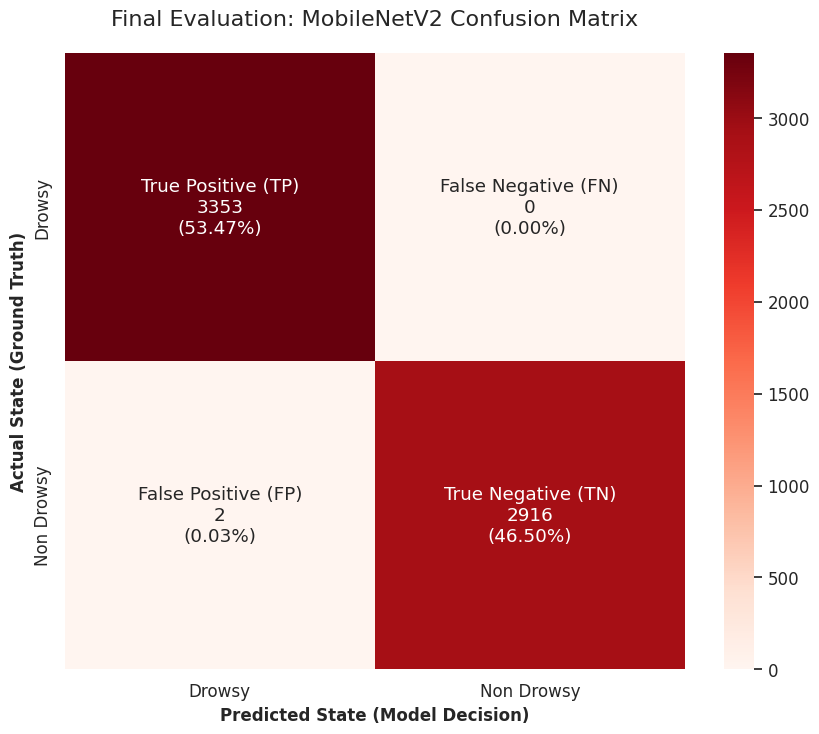

In [43]:

cm = confusion_matrix(y_true_mob, y_pred_mob)


class_names = list(test_generator_mobilenet.class_indices.keys())

group_names = ['True Positive (TP)', 'False Negative (FN)',
               'False Positive (FP)', 'True Negative (TN)']

group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(10, 8))
sns.set(font_scale=1.1)
ax = sns.heatmap(cm, annot=labels, fmt='', cmap='Reds', cbar=True,
                 xticklabels=class_names, yticklabels=class_names)

plt.title('Final Evaluation: MobileNetV2 Confusion Matrix', fontsize=16, pad=20)
plt.xlabel('Predicted State (Model Decision)', fontsize=12, fontweight='bold')
plt.ylabel('Actual State (Ground Truth)', fontsize=12, fontweight='bold')

plt.show()

###  MobileNetV2 – Confusion Matrix Analysis

- **True Negatives (TN):** 3351 (53.44%)
- **False Positives (FP):** 2 (0.03%)
- **False Negatives (FN):** 0 (0.00%)
- **True Positives (TP):** 2918 (46.53%)

**Observations:**
- Zero false negatives → no drowsy cases were missed.
- Extremely low false positives.
- Model is highly reliable but conservative.
- Suitable for safety-critical systems when combined with temporal logic.


# Final Classification Report

In [44]:
from sklearn.metrics import classification_report
print("\nFinal Classification Report ")
print(classification_report(y_true_mob, y_pred_mob, target_names=class_names))


Final Classification Report 
              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      3353
  Non Drowsy       1.00      1.00      1.00      2918

    accuracy                           1.00      6271
   macro avg       1.00      1.00      1.00      6271
weighted avg       1.00      1.00      1.00      6271

